In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# ==========================================
# FUNGSI BANTUAN (TRAINING & EVALUASI)
# ==========================================
def train_evaluate(X, y, title):
    # Split Data (80% Train, 20% Test)
    # PENTING: random_state harus sama agar perbandingan 'apple-to-apple'
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Inisialisasi Model Decision Tree
    # Kita pakai 'entropy' sesuai eksperimen sebelumnya
    model = DecisionTreeClassifier(criterion='entropy', random_state=42)
    
    # Latih Model
    model.fit(X_train, y_train)
    
    # Prediksi
    y_pred = model.predict(X_test)
    
    # Evaluasi
    acc = accuracy_score(y_test, y_pred)
    print(f"--- HASIL MODEL: {title} ---")
    print(f"Akurasi: {acc * 100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Return model dan data test untuk visualisasi nanti
    return model, acc, X_test, y_test, y_pred

In [5]:
# ==========================================
# SKENARIO 1: MENGGUNAKAN DATA MENTAH
# ==========================================
# Load Data Mentah
try:
    df_raw = pd.read_csv('../data/cleveland.csv')
    
    # 1. Handle Missing Value '?' (Minimal cleaning agar tidak error)
    df_raw = df_raw.replace('?', np.nan).dropna()
    
    # 2. RENAME KOLOM (Agar konsisten dengan Data Bersih)
    kamus_nama_lengkap = {
        'age': 'Age', 'sex': 'Sex', 'cp': 'Chest_Pain_Type',
        'trestbps': 'Resting_Blood_Pressure', 'chol': 'Serum_Cholesterol',
        'fbs': 'Fasting_Blood_Sugar', 'restecg': 'Resting_ECG',
        'thalach': 'Max_Heart_Rate_Achieved', 'exang': 'Exercise_Induced_Angina',
        'oldpeak': 'ST_Depression', 'slope': 'ST_Slope',
        'ca': 'Number_of_Major_Vessels', 'thal': 'Thalassemia',
        'label': 'Target_Diagnosis'
    }
    df_raw.rename(columns=kamus_nama_lengkap, inplace=True)

    # 3. Encoding Label ('A'->0, Lainnya->1)
    # Target asli sekarang bernama 'Target_Diagnosis'
    df_raw['Target_Encoded'] = df_raw['Target_Diagnosis'].apply(lambda x: 0 if x == 'A' else 1)
    
    # 4. Pisahkan X dan y
    # Kita gunakan semua fitur mentah (tanpa seleksi)
    X_raw = df_raw.drop(['Target_Diagnosis', 'Target_Encoded'], axis=1)
    y_raw = df_raw['Target_Encoded']
    
    # Jalankan Training
    model_raw, acc_raw, X_test_raw, y_test_raw, y_pred_raw = train_evaluate(X_raw, y_raw, "DATA MENTAH (Raw)")
    
except Exception as e:
    print(f"Gagal memproses data mentah: {e}")
    acc_raw = 0

--- HASIL MODEL: DATA MENTAH (Raw) ---
Akurasi: 80.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80        32
           1       0.76      0.86      0.81        29

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.81      0.80      0.80        61



In [6]:
# ==========================================
# SKENARIO 2: MENGGUNAKAN DATA BERSIH 
# ==========================================
# Load Data Hasil Olahan Kita
try:
    df_clean = pd.read_csv('../data/cleveland_normalized.csv')
    
    # Data ini sudah bersih, angka semua, dan fitur lemah sudah dibuang.
    # Kolom target ada di paling kanan: 'Target_Encoded'
    
    X_clean = df_clean.drop('Target_Encoded', axis=1)
    y_clean = df_clean['Target_Encoded']
    
    # Jalankan Training
    model_clean, acc_clean, X_test_clean, y_test_clean, y_pred_clean = train_evaluate(X_clean, y_clean, "DATA BERSIH (Processed)")

except Exception as e:
    print(f"Gagal memproses data bersih: {e}")
    acc_clean = 0

--- HASIL MODEL: DATA BERSIH (Processed) ---
Akurasi: 83.61%

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84        32
           1       0.81      0.86      0.83        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [7]:
# ==========================================
# PERBANDINGAN AKHIR 
# ==========================================
print(f"1. Akurasi Data Mentah : {acc_raw * 100:.2f}%")
print(f"2. Akurasi Data Bersih : {acc_clean * 100:.2f}%")

improvement = acc_clean - acc_raw
if improvement > 0:
    print(f"\n KESIMPULAN: Preprocessing berhasil meningkatkan akurasi sebesar {improvement * 100:.2f}%!")
    print("(MinMax Scaling + Feature Selection + Entropy terbukti efektif)")
else:
    print("\nℹ KESIMPULAN: Akurasi sama/turun. Decision Tree memang robust terhadap data kotor.")

1. Akurasi Data Mentah : 80.33%
2. Akurasi Data Bersih : 83.61%

 KESIMPULAN: Preprocessing berhasil meningkatkan akurasi sebesar 3.28%!
(MinMax Scaling + Feature Selection + Entropy terbukti efektif)


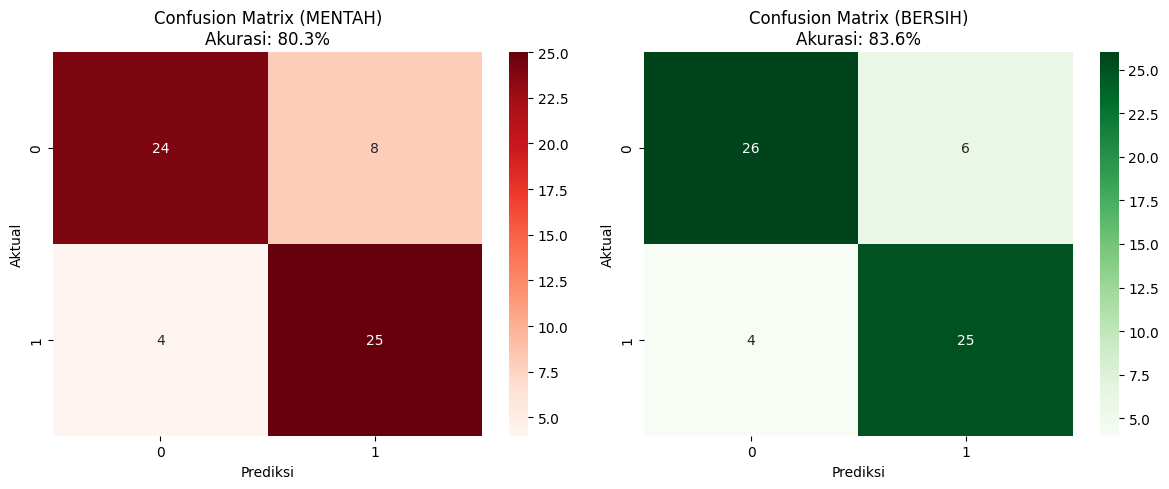

In [8]:
# ==========================================
# VISUALISASI CONFUSION MATRIX 
# ==========================================
plt.figure(figsize=(12, 5))

# Plot Mentah
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test_raw, y_pred_raw), annot=True, fmt='d', cmap='Reds')
plt.title(f'Confusion Matrix (MENTAH)\nAkurasi: {acc_raw*100:.1f}%')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

# Plot Bersih
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test_clean, y_pred_clean), annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix (BERSIH)\nAkurasi: {acc_clean*100:.1f}%')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

plt.tight_layout()
plt.show()

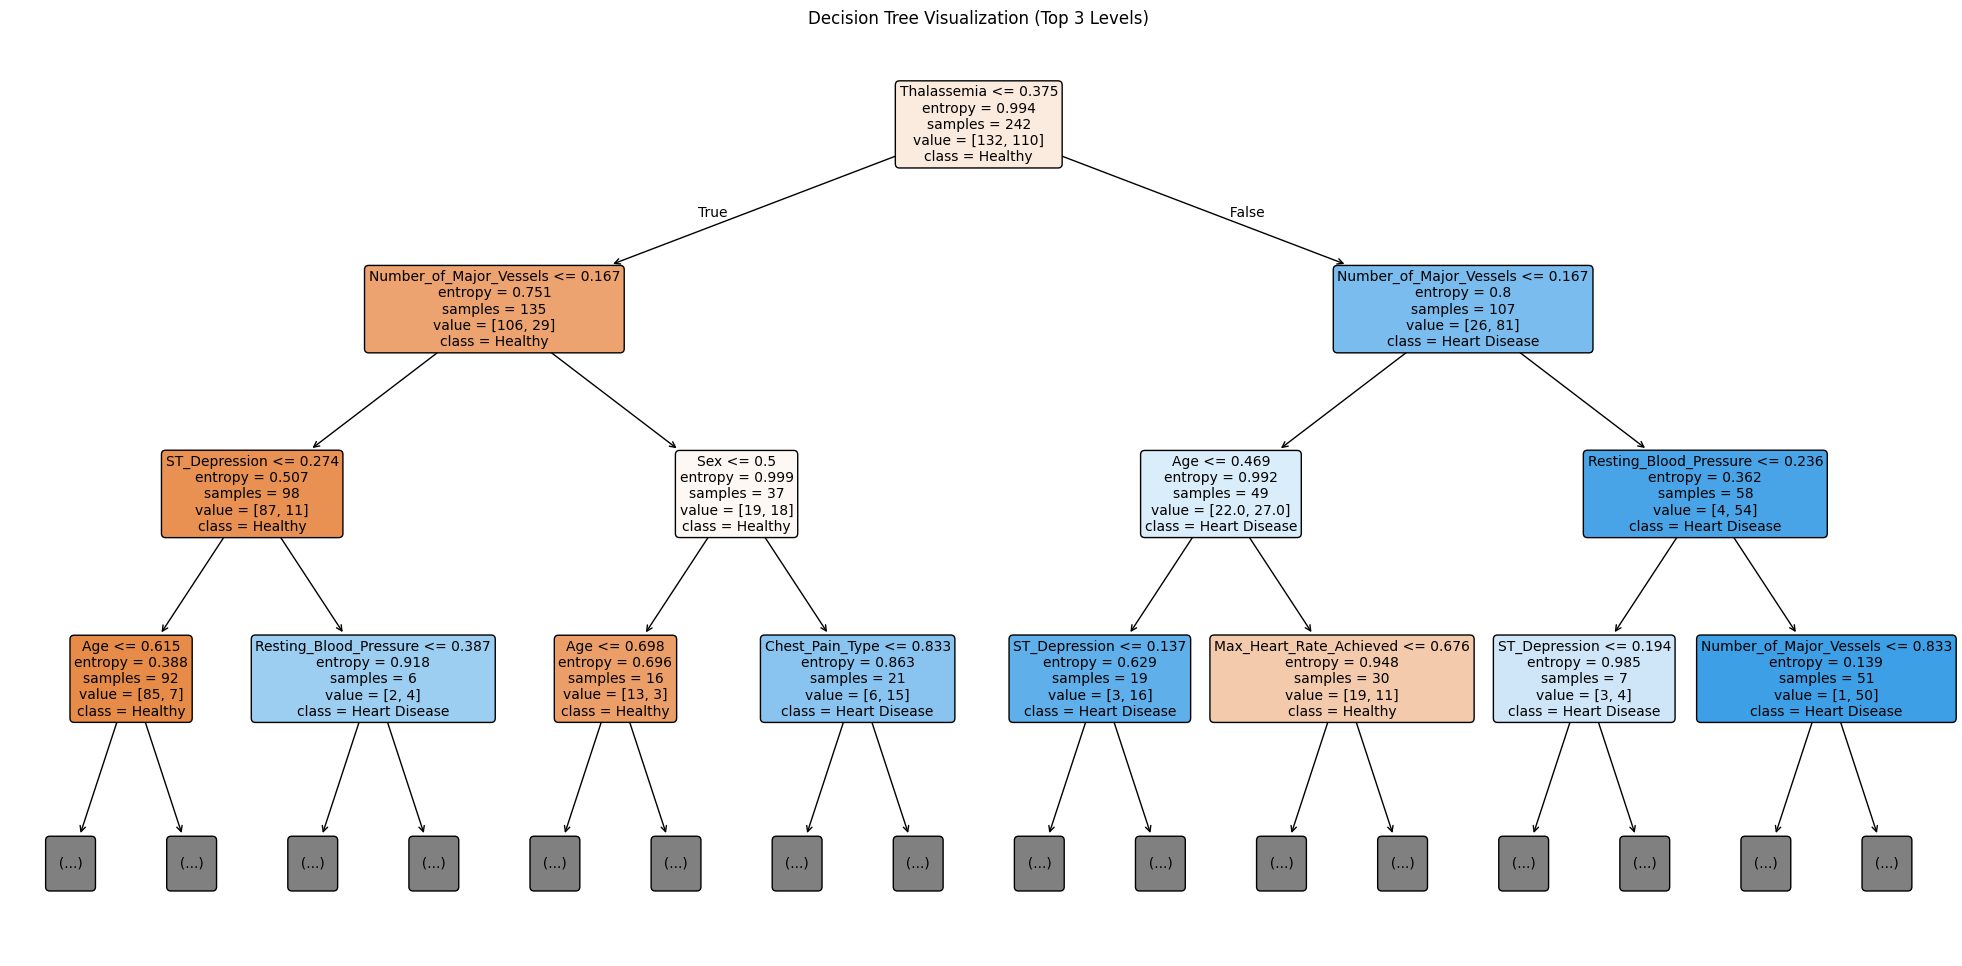

In [9]:
# ==========================================
# VISUALISASI POHON KEPUTUSAN
# ==========================================
plt.figure(figsize=(25, 12))

plot_tree(model_clean, 
          feature_names=X_clean.columns, 
          class_names=['Healthy', 'Heart Disease'], # Label kelas diubah ke Inggris
          filled=True, 
          rounded=True, 
          fontsize=10,
          max_depth=3) # Kita batasi depth=3 biar gambarnya terbaca di slide

plt.title("Decision Tree Visualization (Top 3 Levels)")
plt.show()